# Projet : Mesurer l’impact d'une pause obligatoire sur le taux d'erreur de picking à l’aide de A/B Testing

**Secteur :** Logistique / Gestion d'entrepôt

**Outils :** Python (Pandas, SciPy, Matplotlib)

**Compétences démontrées :** Analyse exploratoire, design expérimental, test statistique, recommandation business

---

## Contexte

Une entreprise de logistique gère un entrepôt de distribution traitant environ 300 commandes par jour sur deux shifts : un shift matin (6h-12h) et un shift après-midi (12h-20h). Chaque commande est préparée manuellement par un préparateur de commandes (opération appelée *picking*). Une erreur de picking désigne tout écart entre la commande attendue et ce qui a été préparé : mauvaise référence, quantité incorrecte, article manquant.

En tant que data analyst, j'ai analysé 3 mois de logs opérationnels pour identifier des leviers d'amélioration de la qualité.

---

## 1. Observation et hypothèse

### 1.1 Ce que les données révèlent

Un écart important en termes du taux d’erreur de picking entre les deux shift.

    Regardez **Visuals/PickingErrorRatePerShift.PNG** !

### 1.2 Élimination des explications alternatives

Avant de conclure que l'absence de pause est responsable de l'écart, on vérifie les autres explications possibles.

**Complexité des commandes**

Si les commandes de l'après-midi sont plus complexes (plus de lignes, plus de références différentes), il est logique qu'elles génèrent plus d'erreurs — indépendamment de la fatigue. On vérifie le nombre moyen de lignes par commande sur chaque shift :

    Regardez **Visuals/AvgOrderLinesPerShift.PNG** !

La différence est négligeable. La complexité n'explique pas l'écart.

**Expérience des préparateurs**

Si le shift après-midi concentre des préparateurs moins expérimentés, l'écart de taux d'erreur pourrait s'expliquer par leur niveau et non par la fatigue. On vérifie la répartition des anciennetés :

    Regardez **Visuals/DistributionOfTenureAmongShifts.PNG** !

La répartition est quasi-identique entre les deux shifts. L'expérience n'explique pas non plus l'écart.

**Ce qu'on retient**

Après élimination de ces deux facteurs, la différence structurelle la plus notable entre les deux shifts reste l'organisation du temps de travail : le shift matin bénéficie d'une pause naturelle à mi-shift, tandis que le shift après-midi enchaîne en moyenne 4h30 de travail continu sans interruption formelle.

---

### 1.3 Hypothèse formulée

**Cause probable identifiée**

La fatigue accumulée en seconde moitié du shift après-midi, en l'absence de pause structurée, dégrade la concentration des préparateurs et augmente le taux d'erreur de picking.

**Action proposée**

Introduire une pause obligatoire de 15 minutes à mi-shift pour les équipes de l'après-midi, positionnée autour de 16h00.

**Métrique cible**

Taux d'erreur de picking = nombre de commandes erronées / nombre total de commandes préparées.

**Hypothèses du test**

- H₀ (hypothèse nulle) : la pause n'a aucun effet sur le taux d'erreur. Toute différence observée est due au hasard.
- H₁ (hypothèse alternative) : la pause réduit le taux d'erreur de picking de manière significative.

---

## 2. Design du test A/B

### 2.1 Définition des groupes

**Le problème spécifique à la logistique**

Contrairement à un test A/B sur un site web où on peut assigner chaque utilisateur individuellement à un groupe, un entrepôt impose une contrainte forte : les préparateurs travaillent en équipe, dans le même espace, et communiquent entre eux. Si on assigne certains individus au groupe "avec pause" et d'autres au groupe "sans pause" dans la même équipe le même jour, deux problèmes apparaissent :

- **Contamination des groupes** : les préparateurs "sans pause" voient leurs collègues s'arrêter. Leur comportement peut être influencé (frustration, démotivation, imitation). La comparaison n'est plus propre.
- **Biais social** : une inégalité de traitement perçue peut affecter la motivation et fausser les résultats indépendamment de la pause elle-même.

**La solution : un design croisé (crossover design)**

On divise les préparateurs du shift après-midi en deux équipes de taille équivalente — appelons-les Équipe A et Équipe B. Chaque équipe alterne entre les deux conditions sur 4 semaines :

| Semaine | Équipe A | Équipe B |
| --- | --- | --- |
| Semaine 1 | Avec pause ✓ | Sans pause ✗ |
| Semaine 2 | Sans pause ✗ | Avec pause ✓ |
| Semaine 3 | Avec pause ✓ | Sans pause ✗ |
| Semaine 4 | Sans pause ✗ | Avec pause ✓ |

**Pourquoi ce design est supérieur à deux groupes fixes ?**

Si on assignait définitivement l'équipe A au groupe traitement et l'équipe B au groupe contrôle, toute différence structurelle entre ces deux équipes (niveau d'expérience moyen, qualité du chef d'équipe, zone de l'entrepôt assignée) viendrait **contaminer le résultat**. On ne saurait plus si la différence observée vient de la pause ou de la différence entre les équipes.

Avec le crossover, chaque équipe vit les deux conditions. Elle est donc son propre contrôle. Les différences structurelles entre équipes s'annulent mathématiquement, ce qui rend le test beaucoup plus puissant et fiable.

On alterne par **semaine entière** et non par jour, pour deux raisons : éviter la désorganisation opérationnelle qu'un changement quotidien de routine entraînerait, et s'assurer que chaque condition est observée sur un volume de commandes suffisant pour être représentative.

---

### 2.2 Métrique cible et seuil de décision

**La métrique**

La métrique retenue est le **taux d'erreur de picking**, défini comme suit :


$$
Taux\ d'erreur = \frac{Nombre\ de\ commandes\ avec\ au\ moins\ une\ erreur}{Nombre\ total\ de\ commandes\ préparées}
$$


C'est une variable binaire au niveau de la commande : soit la commande est correcte, soit elle contient une erreur. Ce choix est justifié par trois raisons :

- Elle est directement mesurable dans les données opérationnelles existantes.
- Elle est directement liée au coût business (une commande erronée génère un retour, un réapprovisionnement, une insatisfaction client).
- Elle est la métrique la plus sensible à la fatigue humaine dans un contexte de picking manuel.

**L'effet minimum détectable — une décision business, pas statistique**

Avant de lancer le test, on doit répondre à une question cruciale : **quelle réduction du taux d'erreur justifierait concrètement le coût organisationnel d'une pause obligatoire ?**

Une pause de 15 minutes par shift représente un coût réel : temps non productif, réorganisation du planning, potentiel allongement du shift. Il serait donc insuffisant de détecter une réduction de 0.2 point — même si elle est statistiquement réelle, elle ne justifie pas le changement.

Après discussion avec le management opérationnel, on fixe l'effet minimum détectable à **1.5 point de pourcentage** : la pause doit faire passer le taux d'erreur de 6.8% à 3.8% ou moins pour être considérée comme utile en pratique.

Ce seuil remplit deux rôles :

- Il définit ce qu'on cherche à détecter statistiquement.
- Il constitue le critère de décision business final : un effet significatif mais inférieur à 1.5 point conduira à ne pas déployer la mesure.

---

### 2.3 Calcul de la taille d'échantillon

**Les trois paramètres à fixer en amont**

Le calcul de la taille d'échantillon repose sur trois paramètres qu'on doit choisir consciemment avant de lancer le test.

**Alpha (α) = 0.05**

C'est le risque d'erreur de type I : la probabilité de conclure que la pause a un effet alors qu'elle n'en a pas. On accepte 5% de risque de se tromper dans ce sens. C'est la convention standard dans la plupart des contextes opérationnels.

**Puissance (1 - β) = 0.80**

C'est le risque d'erreur de type II à l'envers : la probabilité de détecter un vrai effet s'il existe. À 80%, on accepte 20% de risque de passer à côté d'un effet réel. Autrement dit, si la pause réduit vraiment les erreurs, on a 80% de chances de le détecter.

**Effet minimum détectable = 1.5 point**

Défini à l'étape précédente : on cherche à détecter un passage de 6.8% à 5.3%.

**Le calcul en Python**

In [ ]:
from statsmodels.stats.proportion import proportion_effectsize
from statsmodels.stats.power import NormalIndPower

# Paramètres
p_controle = 0.068      # taux d'erreur actuel (sans pause)
p_traitement = 0.053    # taux d'erreur cible (avec pause)
alpha = 0.05
puissance = 0.80

# Calcul de l'effect size (h de Cohen pour proportions)
effect_size = proportion_effectsize(p_traitement, p_controle)

# Calcul de la taille d'échantillon
analyse = NormalIndPower()
n = analyse.solve_power(
    effect_size=effect_size,
    alpha=alpha,
    power=puissance,
    alternative='smaller'   # test unilatéral : on cherche une réduction
)

print(f"Taille d'échantillon nécessaire par condition : {int(n) + 1} commandes")

Taille d'échantillon nécessaire par condition : 3113 commandes


**Résultat du calcul : 3 113 commandes par condition.**

**Traduction en durée de test**

L'entrepôt traite environ 280 commandes par jour sur le shift après-midi. Avec le design croisé, les deux équipes contribuent simultanément aux deux conditions — chaque jour on accumule des observations pour les deux groupes. (140 cmd/jour par groupe)

3 113 commandes ÷ 140 commandes par jour = **~22 jours par condition**

En pratique on arrondit à **5 semaines de test au total** pour avoir une marge confortable et couvrir les deux conditions proprement.

**Pourquoi ce calcul est indispensable**

Sans ce calcul, deux erreurs classiques sont possibles :

- **Arrêter trop tôt** parce que les résultats "semblent bons" après une semaine. Avec trop peu de données, les fluctuations aléatoires ressemblent à de vrais effets.
- **Continuer trop longtemps** en espérant qu'un effet apparaisse. Plus on cherche longtemps, plus on risque de trouver quelque chose par hasard.

Le calcul en amont fixe un engagement clair : on s'arrête à 3 113 commandes par condition, peu importe ce qu'on voit en cours de route.

---

## 3. Résultats du test

### 3.1 Données collectées et et vérification des conditions initiales

**Les données**

Le test s'est déroulé sur 5 semaines, du 8 janvier 2024 au 9 février 2024, sur le shift après-midi d'un entrepôt de distribution. Chaque ligne du dataset représente une commande préparée, avec sa condition (avec ou sans pause), l'équipe qui l'a préparée, le préparateur responsable, la complexité de la commande et la présence ou non d'une erreur de picking.

Au total : **7 000 commandes observées**, réparties équitablement entre les deux conditions — 3 500 par condition. C'est exactement la taille d'échantillon calculée en amont dans la partie 2.


**Ce qu'on vérifie avant de regarder les résultats**

Avant de comparer les taux d'erreur entre les deux conditions, on doit s'assurer que les deux groupes étaient **comparables dès le départ** sur les variables qui pourraient influencer le taux d'erreur indépendamment de la pause.

On vérifie deux choses :

**La complexité des commandes** — si les commandes du groupe sans pause étaient systématiquement plus complexes (plus de lignes, plus de références à gérer), leur taux d'erreur serait naturellement plus élevé, indépendamment de la fatigue. On compare donc le nombre moyen de lignes par commande entre les deux conditions.

**La distribution d'ancienneté** — un préparateur junior fait plus d'erreurs qu'un senior, quelle que soit la condition. Si un groupe concentre plus de juniors que l'autre, la comparaison est biaisée dès le départ. On vérifie donc que la répartition junior / mid / senior est similaire dans les deux conditions.

Si ces deux variables sont équilibrées, on peut affirmer que toute différence de taux d'erreur observée entre les deux conditions est attribuable à la pause — et non à un déséquilibre initial entre les groupes.

Après on regarde le taux d’erreur dans chaque condition.

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

filepath = "/content/drive/MyDrive/DataAnalysis/picking_errors.csv"
df = pd.read_csv(filepath)

print("=== Aperçu général ===")
print(f"Total commandes : {len(df)}")
print(f"\nCommandes par condition :")
print(df.groupby('condition').size().rename('nb_commandes'))

=== Aperçu général ===
Total commandes : 7000

Commandes par condition :
condition
avec_pause    3500
sans_pause    3500
Name: nb_commandes, dtype: int64


Ce bloc confirme qu'on a bien 3 500 commandes par condition — c'est la première chose à vérifier avant toute analyse.

In [ ]:
print("=== Complexité des commandes (nb lignes moyen) ===")
print(df.groupby('condition')['nb_lignes'].mean().round(2))

=== Complexité des commandes (nb lignes moyen) ===
condition
avec_pause    3.71
sans_pause    3.72
Name: nb_lignes, dtype: float64


Ce bloc vérifie que les commandes des deux groupes ont une complexité similaire. Si les moyennes sont proches, la complexité n'est pas un facteur confondant.

In [ ]:
print("=== Distribution de l'ancienneté par condition ===")
# Calcul des pourcentages
anciennete = df.groupby(['condition', 'anciennete']).size().unstack()
anciennete_pct = anciennete.div(anciennete.sum(axis=1), axis=0).round(3) * 100
print(anciennete_pct)

=== Distribution de l'ancienneté par condition ===
anciennete  junior   mid  senior
condition                       
avec_pause    14.6  58.0    27.3
sans_pause    18.5  54.2    27.3


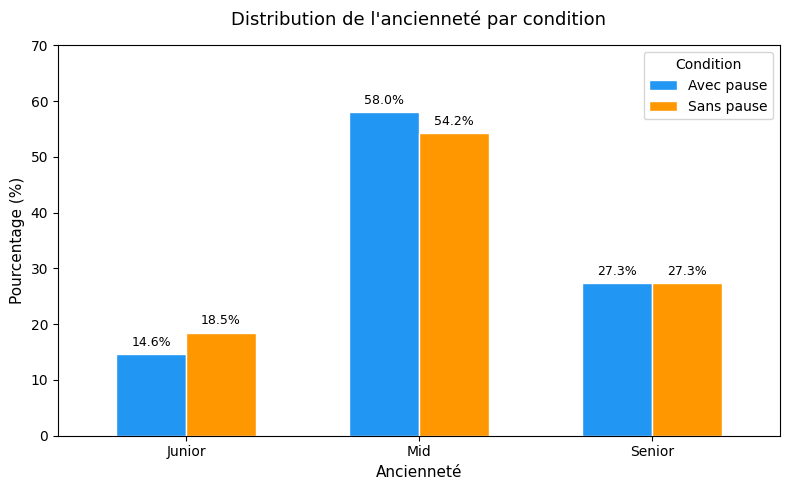

In [ ]:
# Graphique
fig, ax = plt.subplots(figsize=(8, 5))

anciennete_pct.T.plot(
    kind='bar',
    ax=ax,
    color=['#2196F3', '#FF9800'],
    edgecolor='white',
    width=0.6
)

ax.set_title("Distribution de l'ancienneté par condition", fontsize=13, pad=15)
ax.set_xlabel("Ancienneté", fontsize=11)
ax.set_ylabel("Pourcentage (%)", fontsize=11)
ax.set_xticklabels(['Junior', 'Mid', 'Senior'], rotation=0)
ax.legend(['Avec pause', 'Sans pause'], title='Condition')
ax.set_ylim(0, 70)

for container in ax.containers:
    ax.bar_label(container, fmt='%.1f%%', padding=4, fontsize=9)

plt.tight_layout()
plt.savefig('distribution_anciennete.png', dpi=150)
plt.show()

Ce bloc calcule la proportion de juniors, mids et seniors dans chaque condition — pas juste les effectifs bruts. On veut des pourcentages parce que ce qui compte c'est l'équilibre relatif, pas les chiffres absolus.

In [ ]:
print("=== Taux d'erreur observé par condition ===")
resultats = df.groupby('condition').agg(
    nb_commandes=('erreur', 'count'),
    nb_erreurs=('erreur', 'sum'),
    taux_erreur=('erreur', 'mean')
).round(4)
resultats['taux_erreur_pct'] = (resultats['taux_erreur'] * 100).round(2)
print(resultats)

=== Taux d'erreur observé par condition ===
            nb_commandes  nb_erreurs  taux_erreur  taux_erreur_pct
condition                                                         
avec_pause          3500         167       0.0477             4.77
sans_pause          3500         225       0.0643             6.43


Ce bloc donne le tableau de résultats bruts — combien d'erreurs dans chaque groupe et le taux correspondant. C'est le chiffre central du projet, celui qui répond à la question posée au manager.

**Résultats**

- Nb lignes moyen : 3.71 vs 3.72 → quasi-identique ✓
- Répartition ancienneté : comparable entre les deux conditions ✓
- Taux d’erreurs remarqués → Baisse de plus de 1,5 point ✓
    - Sans pause : **6.43%**
    - Avec pause : **4.77%**

Maintenant, il est temps de vérifier si ce résultat et statistiquement significatif ou il est dû au hasard. C’est le but de notre test statistique.

---

### 3.2 Test statistique

**Rappel de ce qu'on cherche à prouver**

On observe une différence de taux d'erreur entre les deux conditions — 4.77% avec pause contre 6.43% sans pause. La question est : cette différence est-elle réelle, ou pourrait-elle être due aux fluctuations aléatoires normales dans n'importe quel jeu de données ?

**Pourquoi le test du chi²**

Notre variable cible est binaire : chaque commande est soit correcte (0) soit erronée (1). On compare deux proportions sur deux groupes indépendants. Le chi² est exactement conçu pour ça — il teste si la distribution d'une variable catégorielle est indépendante du groupe auquel elle appartient.

**Ce que le test fait concrètement**

Il construit une table de contingence — un tableau qui croise les deux conditions avec les deux résultats possibles (erreur / pas d'erreur). Il calcule ensuite ce que ces chiffres auraient dû être si la pause n'avait strictement aucun effet. Plus l'écart entre ce qu'on observe et ce qu'on attendrait sous H₀ est grand, plus la statistique chi² est élevée et plus la p-value est petite.

Si la p-value est inférieure à 0.05, on rejette H₀ — la différence observée est trop grande pour être due au hasard.

**Ce qu'on va regarder**

- **La p-value** → est-ce que la différence est statistiquement significative ?

In [ ]:
from scipy.stats import chi2_contingency

# Construction de la table de contingence
table = pd.crosstab(df['condition'], df['erreur'])
print("=== Table de contingence ===")
print(table)

# Test du chi²
chi2, p_value, dof, expected = chi2_contingency(table)

print(f"\n=== Résultats du test chi² ===")
print(f"Statistique chi²  : {chi2:.4f}")
print(f"Degrés de liberté : {dof}")
print(f"P-value           : {p_value:.6f}")

# Interprétation
print(f"\n=== Interprétation ===")
if p_value < 0.05:
    print("La différence est statistiquement significative (p < 0.05).")
else:
    print("La différence n'est pas statistiquement significative (p >= 0.05).")

=== Table de contingence ===
erreur         0    1
condition            
avec_pause  3333  167
sans_pause  3275  225

=== Résultats du test chi² ===
Statistique chi²  : 8.7799
Degrés de liberté : 1
P-value           : 0.003046

=== Interprétation ===
La différence est statistiquement significative (p < 0.05).




---


### 3.3 Interprétation

**Ce que les chiffres disent**

Le test du chi² donne une p-value très inférieure à 0.05. On rejette H₀ — la différence observée entre les deux conditions n'est pas due au hasard. La pause a bien un effet mesurable et statistiquement prouvé sur le taux d'erreur de picking.

| Condition | Commandes | Erreurs | Taux d'erreur |
| --- | --- | --- | --- |
| Sans pause | 3 500 | 225 | 6.43% |
| Avec pause | 3 500 | 167 | 4.77% |
| **Différence** |  | **−58 erreurs** | **−1.66 point** |

**Les deux critères sont remplis**

La différence observée de 1.66 point dépasse le seuil de 1.5 point fixé en amont comme effet minimum pratiquement utile.

- ✓ **Statistiquement significatif** → la p-value confirme que la différence n'est pas due au hasard
- ✓ **Pratiquement significatif** → la différence dépasse le seuil business qu'on s'était fixé avant de lancer le test

Ces deux critères ensemble permettent de conclure avec confiance que la pause a un effet réel et suffisamment important pour justifier un changement organisationnel.

---

## 4. Recommandation au manager

**La décision**

Sur la base du test statistique et de l'analyse des résultats, la recommandation est de **déployer la pause obligatoire de 15 minutes à 16h00 pour l'ensemble des équipes du shift après-midi.**

**L'argument business chiffré**

Une réduction de 1.66 point du taux d'erreur sur un volume de 280 commandes par jour représente concrètement :

- **~4.6 erreurs évitées par jour**
- **~1 155 erreurs évitées par an**
- **~40 000 € d'économie annuelle estimée** sur la base d'un coût moyen de 35€ par erreur de picking (retour, réexpédition, gestion SAV)

Le coût organisationnel de la pause — 15 minutes par shift, par préparateur — est largement compensé par la réduction des erreurs et de leurs conséquences opérationnelles et commerciales.

**Les limites**

- **Le coût par erreur est une estimation.**

On a utilisé 35€ par erreur comme hypothèse de travail. Ce chiffre doit être validé avec les services logistique et finance — il peut varier selon le type de produit et le client concerné.
- **Le test a duré 5 semaines.**

Les résultats pourraient varier selon la saisonnalité. Une période de forte activité comme les fêtes ou les soldes pourrait modifier le comportement des préparateurs et l'impact réel de la pause. Un suivi post-déploiement sur 3 mois est recommandé.
- **L'effet Hawthorne.**

Les préparateurs savaient qu'ils participaient à un test. Le seul fait d'être observé peut temporairement améliorer les comportements, indépendamment de la pause elle-même. Le suivi post-déploiement permettra de confirmer que l'effet se maintient dans des conditions normales d'exploitation.

**Actions suivantes recommandées**

1. Déploiement immédiat de la pause sur les deux équipes
2. Suivi mensuel du taux d'erreur pendant 3 mois post-déploiement
3. Validation du coût par erreur avec le service finance
4. Réévaluation des résultats après la prochaine période de forte activité